<a href="https://colab.research.google.com/github/jhasankbharadwaj/Mtech_Aiml_Projects-/blob/jhasank/2025AG05622_cnn_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEEP NEURAL NETWORKS – ASSIGNMENT: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning


**STUDENT INFORMATION (REQUIRED – DO NOT DELETE)**

BITS ID : 2025AG05622

Name  : T V M V C JHASANK BHARADWAJ

Email  : 2025ag05622@wilp.bits-pilani.ac.in

Date   : 20-04-2026


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50

from PIL import Image
import time, json, os, math

print("TensorFlow version:", tf.__version__)
print("All libraries loaded ✓")


### Download the Dataset from Kaggle

hear using the **Fresh and Stale Images of Fruits and Vegetables** dataset by raghavrpotdar.

**What is in it?**  
Images of 6 items — Apple, Banana, BitterGourd, Capsicum, Orange, Tomato — each photographed in two conditions: **fresh** and **stale** (rotten). That gives us **12 classes** total, with roughly **1,000–1,200 images per class** — well above the 500/class minimum the assignment requires.

- Real-world food quality control problem (detecting spoiled produce before shipping)  
- 12 balanced classes — perfect for seeing a clear comparison between custom CNN and transfer learning  
- Precision is the natural primary metric: falsely calling a stale item fresh (false positive) is the costly mistake



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Then update DATASET_PATH WITH DRIVE PATH.")
DATASET_PATH = "/content/drive/MyDrive/projects/newdataset"



Mounted at /content/drive
Then update DATASET_PATH WITH DRIVE PATH.


### using  Dataset  Filling **Metadata**

hear  fill in the assignment's required metadata fields.  
These same variables are used at the end to generate the auto-grader JSON — so do not skip them.

**About the train/test split:**  
Because the dataset has no pre-existing split, we use `ImageDataGenerator` with `validation_split=0.1`.  
This automatically assigns a random 90% of images in each class to training and the remaining 10% to validation.  
We fix `seed=42` in both generators so the split is identical and reproducible every time the notebook runs.


In [ ]:
# ── Required metadata ─────────────────────────────────────────────────────
dataset_name    = "Fresh and Stale Images of Fruits and Vegetables"
dataset_source  = "https://www.kaggle.com/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables"
n_classes       = 4     #(selected classes only fruites)          # 6 items × 2 conditions (fresh / stale)
image_shape     = [224, 224, 3]
problem_type    = "classification"
train_test_ratio = "90/10"
primary_metric="Precision"

metric_justification = (
    "Precision is chosen as the primary metric because falsely classifying "
    "a stale item as fresh (false positive) is the most harmful error in a "
    "food quality control context — it results in spoiled produce reaching "
    "consumers. Precision penalises this specific error directly."
)

print("Configuration set.")
print(f"Dataset  : {dataset_name}")
print(f"Classes  : {n_classes}")
print(f"Metric   : {primary_metric}")


Configuration set.
Dataset  : Fresh and Stale Images of Fruits and Vegetables
Classes  : 6
Metric   : Precision


###  Explore the Data

Before writing a single line of model code,to understand the dat balance by ploting them and checking roughly equal counts across classes.


/tmp/ipykernel_4019/2323325593.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


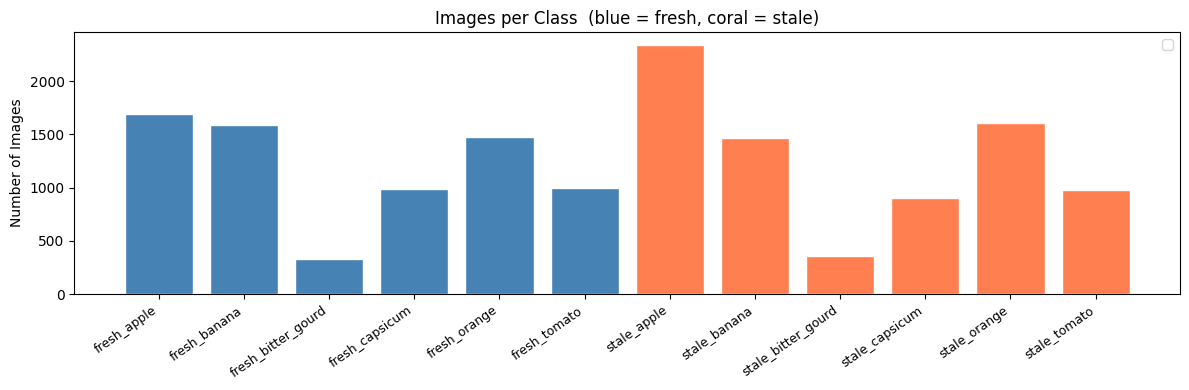

In [ ]:
class_names  = sorted(os.listdir(DATASET_PATH))
class_counts = {}

for cls in class_names:
    cls_dir = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_dir):
        count = len([
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[cls] = count

n_samples     = sum(class_counts.values())
min_per_cls   = min(class_counts.values())
max_per_cls   = max(class_counts.values())
avg_per_cls   = int(n_samples / len(class_counts))
samples_per_class = f"min: {min_per_cls}, max: {max_per_cls}, avg: {avg_per_cls}"




# ── Bar chart ──────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
colors = ['steelblue' if 'fresh' in c else 'coral' for c in class_counts.keys()]
plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.ylabel("Number of Images")
plt.title("Images per Class  (blue = fresh, coral = stale)")
plt.legend()
plt.tight_layout()
plt.show()


due to computational contraints switching to fruites only and making a custom dataset out of it selecting only the data related to fruits.

In [ ]:
import os
import matplotlib.pyplot as plt

# 1. Define the keywords for fruits in this specific dataset
fruit_keywords = ['apple','orange']

# 2. Filter class names to include ONLY the fruit categories
# This looks for any folder name that contains one of our keywords
all_folders = sorted(os.listdir(DATASET_PATH))
class_names = [cls for cls in all_folders if any(fruit in cls.lower() for fruit in fruit_keywords)]

# 3. Proceed with your counting logic as before
class_counts = {}

for cls in class_names:
    cls_dir = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_dir):
        count = len([
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[cls] = count

# 4. Calculate Stats (now only for fruits)
n_samples = sum(class_counts.values())
min_per_cls = min(class_counts.values())
max_per_cls = max(class_counts.values())
avg_per_cls = int(n_samples / len(class_counts))
samples_per_class = f"min: {min_per_cls}, max: {max_per_cls}, avg: {avg_per_cls}"

print(f"Filtered classes: {class_names}")
print(f"Total fruit images: {n_samples}")

Filtered classes: ['fresh_apple', 'fresh_banana', 'fresh_orange', 'stale_apple', 'stale_banana', 'stale_orange']
Total fruit images: 10174


/tmp/ipykernel_4019/711433477.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


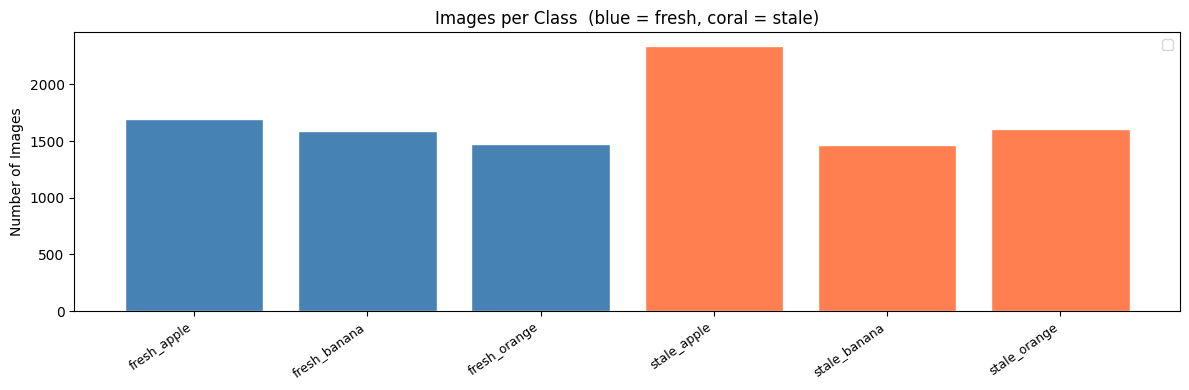

In [ ]:
n_samples     = sum(class_counts.values())
min_per_cls   = min(class_counts.values())
max_per_cls   = max(class_counts.values())
avg_per_cls   = int(n_samples / len(class_counts))
samples_per_class = f"min: {min_per_cls}, max: {max_per_cls}, avg: {avg_per_cls}"




# ── Bar chart ──────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
colors = ['steelblue' if 'fresh' in c else 'coral' for c in class_counts.keys()]
plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.ylabel("Number of Images")
plt.title("Images per Class  (blue = fresh, coral = stale)")
plt.legend()
plt.tight_layout()
plt.show()


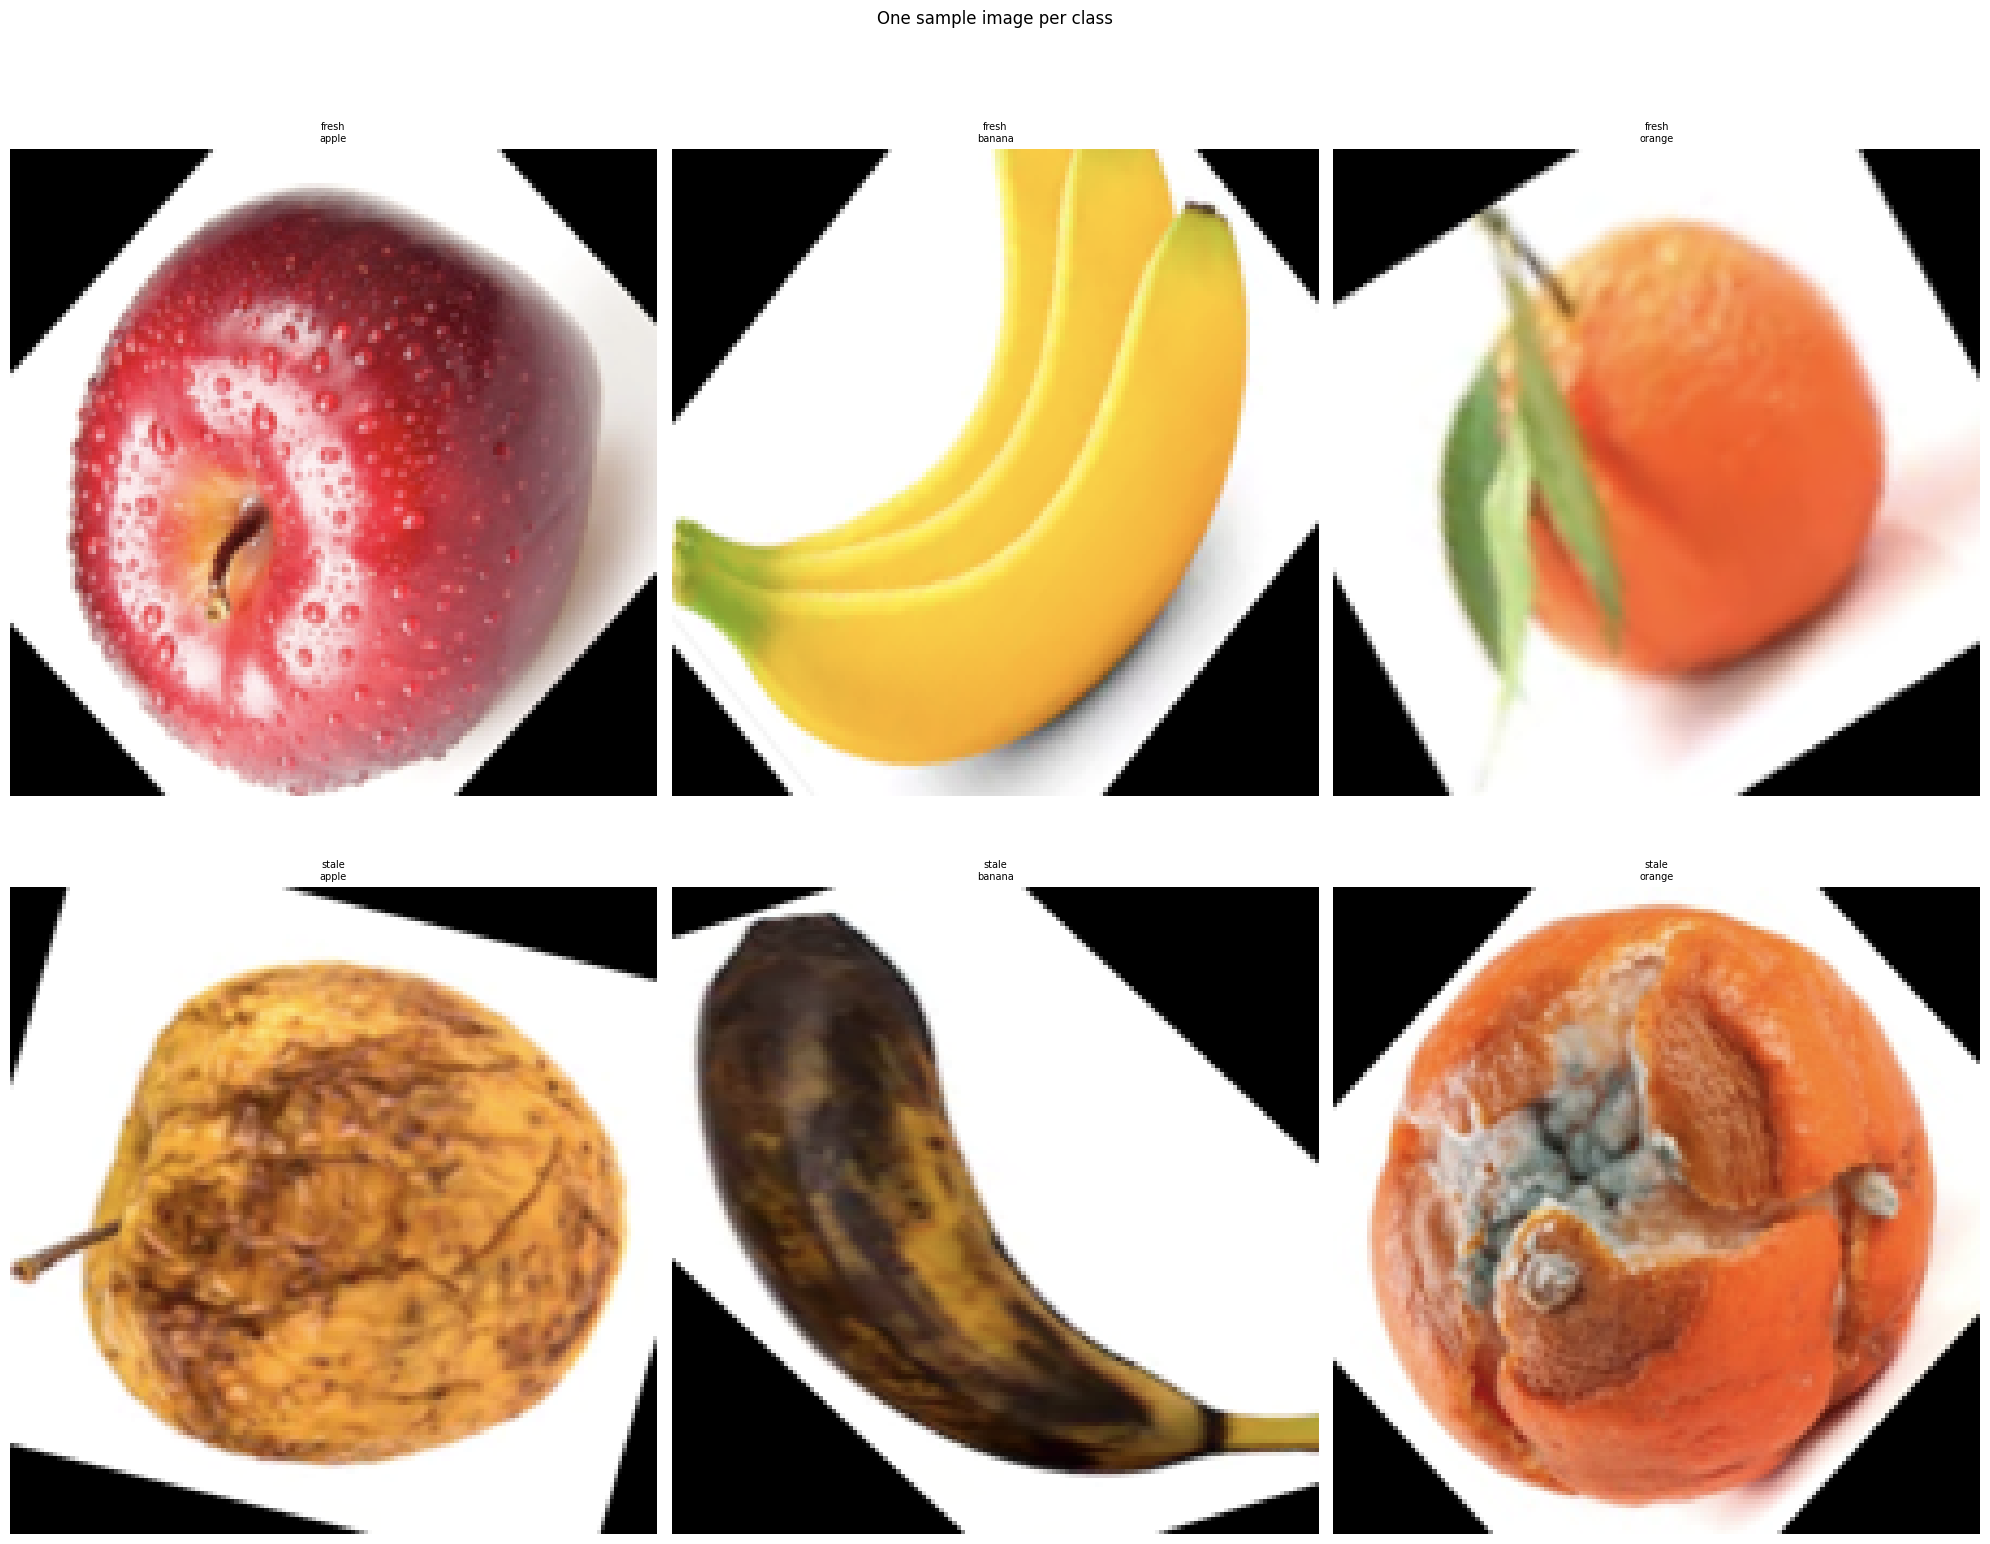

In [ ]:
n_cols = 2
n_rows = math.ceil(len(class_counts) / n_cols)   # 2 rows of 6

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16))
axes = axes.flatten()

for ax, cls in zip(axes, class_counts.keys()):
    cls_dir  = os.path.join(DATASET_PATH, cls)
    img_file = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))][1]
    img = Image.open(os.path.join(cls_dir, img_file)).resize((150, 150))
    ax.imshow(img)
    ax.set_title(cls.replace('_', '\n'), fontsize=7)
    ax.axis('off')

# hide any unused axes
for ax in axes[len(class_counts):]:
    ax.axis('off')

plt.suptitle("One sample image per class", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### Preprocessing and 90/10 Train/Test Split

**normalise**  
Pixel values go from 0 to 255. Neural networks learn better when inputs are small numbers close to 0,
so we divide by 255 to get values between 0 and 1.

**validation_spliting**  
This dataset has one flat folder per class — no pre-made train/test folders.
`ImageDataGenerator(validation_split=0.1)` automatically reserves 10% of images from each class
for validation and uses the other 90% for training. Using `seed=42` in both generators guarantees
that the same images always land in the same subset, making the notebook fully reproducible.

*note- imagedatagenerator is an predefined class in tensorflow for data augmentation and processing (scaling , split,normalization,adjust lighting, etc. ) *

**Why data augmentation on training only**  
We randomly flip, rotate, and zoom training images to teach the model that the same fruit looks
different from different angles. We never augment validation images — we need those unchanged
so we can measure performance fairly.
and also generate some more data to train .


In [ ]:
IMAGE_SIZE  = (224, 224)   # as using resnet50 for transferlearning.
BATCH_SIZE  = 64  # tried with 32 due to comuputation contraint shifted to 64
SPLIT       = 0.10

train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,   # normalise pixels to [0, 1]
    validation_split   = SPLIT,       # holds out 10% for validation
    rotation_range     = 20,          # randomly rotate up to 20°
    width_shift_range  = 0.1,         # shift image left/right
    height_shift_range = 0.1,         # shift image up/down
    horizontal_flip    = True,        # randomly mirror the image
    zoom_range         = 0.1          # randomly zoom in/out
)

# ── Validation generator: normalise ONLY — no augmentation ────────────────
val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = SPLIT          # must match train_datagen
)

# ── Create the generators — seed must be the same in both ─────────────────
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes = class_names, # selected classes.
    subset      = "training",         # picks the 90%
    shuffle     = True,
    seed        = 42
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes = class_names, #selected clasees .
    subset      = "validation",       # picks the 10%
    shuffle     = False,              # keep order fixed for metric calculation
    seed        = 42
)

train_samples = train_generator.samples
test_samples  = val_generator.samples

print(f"Training images   : {train_samples}  (90%)")
print(f"Testing images : {test_samples}  (10%)")
print(f"Class mapping     : {train_generator.class_indices}")


Found 9160 images belonging to 6 classes.
Found 1014 images belonging to 6 classes.
Training images   : 9160  (90%)
Testing images : 1014  (10%)
Class mapping     : {'fresh_apple': 0, 'fresh_banana': 1, 'fresh_orange': 2, 'stale_apple': 3, 'stale_banana': 4, 'stale_orange': 5}


###  Print Dataset Summary

A clean summary printout for the auto-grader and reviewer to confirm the setup at a glance.


In [ ]:
print("=" * 65)
print("DATASET INFORMATION")
print("=" * 65)
print(f"Dataset        : {dataset_name}")
print(f"Source         : {dataset_source}")
print(f"Total images   : {n_samples}")
print(f"Classes        : {n_classes}")
print(f"Per class      : {samples_per_class}")
print(f"Image shape    : {image_shape}")
print(f"Train/Test     : {train_test_ratio}")
print(f"Train samples  : {train_samples}")
print(f"Test samples   : {test_samples}")
print(f"Split method   : ImageDataGenerator validation_split=0.10, seed=42")
print(f"Primary metric : {primary_metric}")
print(f"Justification  : {metric_justification}")


DATASET INFORMATION
Dataset        : Fresh and Stale Images of Fruits and Vegetables
Source         : https://www.kaggle.com/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables
Total images   : 10174
Classes        : 6
Per class      : min: 1467, max: 2342, avg: 1695
Image shape    : [224, 224, 3]
Train/Test     : 90/10
Train samples  : 9160
Test samples   : 1014
Split method   : ImageDataGenerator validation_split=0.10, seed=42
Primary metric : Precision
Justification  : Precision is chosen as the primary metric because falsely classifying a stale item as fresh (false positive) is the most harmful error in a food quality control context — it results in spoiled produce reaching consumers. Precision penalises this specific error directly.


---
## Part 2 – Custom CNN Implementation

---

###  Building the Custom CNN Architecture

We build a convolutional neural network from scratch — every layer is ours, no pre-trained weights.
Think of it as stacking building blocks:

| Layer | What it does |
|---|---|
| `Conv2D` | Scans the image with a small filter to find edges, colours, and textures |
| `BatchNormalization` | Keeps numbers inside the network in a healthy range so training is stable |
| `MaxPooling2D` | Shrinks the feature map by keeping the strongest value in each region — cuts computation |
| `GlobalAveragePooling2D` | **MANDATORY** — averages each feature map to a single number. Far fewer parameters than Flatten, so less overfitting |
| `Dropout` | Randomly switches off neurons during training, forcing the network to not rely on any one path |
| `Dense + Softmax` | Final layer: converts the pooled features to a probability for each of the 12 classes |




In [ ]:
def build_custom_cnn(input_shape, n_classes):
    """
    Custom CNN built from scratch.
    Architecture: 2 × (Conv → BN → MaxPool) → GAP → Dropout → Dense(softmax)

    Args
    ----
    input_shape : tuple  e.g. (224, 224, 3)
    n_classes   : int    number of output classes (12 for this dataset)

    Returns
    -------
    model : compiled Keras Sequential model
    """
    model = models.Sequential([

        # ── Block 1 ── 32 filters, 3×3 kernel ────────────────────────────
        # Detects basic edges and colour boundaries
        layers.Conv2D(32, (3, 3), activation='relu',
                      padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),   # 224×224 → 112×112

        # ── Block 2 ── 64 filters ────────────────────────────────────────
        # Builds on Block 1 — detects simple shapes
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),   # 112×112 → 56×56

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=0.001),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy' ,'precision']
    )

    return model

In [ ]:

# ── Build the model ────────────────────────────────────────────────────────
custom_cnn = build_custom_cnn(tuple(image_shape), n_classes)
custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,878 (1.49 MB)

 Trainable params: 390,918 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

###  Training the Custom CNN

**One epoch** = the model sees every training image once.  
We run for up to **25 epochs** with two safety callbacks:

- **EarlyStopping** — if validation loss does not improve for 5 epochs in a row, training stops early.
  This saves time and prevents the model from overfitting (memorising the training set).
- **ReduceLROnPlateau** — if progress stalls, the learning rate is halved.
  Think of it as taking smaller steps when you are nearly at the destination.


In [ ]:
print("=" * 65)
print("CUSTOM CNN TRAINING")
print("=" * 65)
# restore_best_weights will help to get me the best weights among the 25  epochs
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

steps_per_epoch  = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(val_generator.samples   / BATCH_SIZE)

custom_cnn_start_time = time.time()

history = custom_cnn.fit(
    train_generator,
    epochs           = 25,
    steps_per_epoch  = steps_per_epoch,
    validation_data  = val_generator,
    validation_steps = validation_steps,
    callbacks        = [early_stop, reduce_lr],
    verbose          = 1
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

custom_cnn_initial_loss = history.history['loss'][0]
custom_cnn_final_loss   = history.history['loss'][-1]
cnn_loss_red_pct = ((custom_cnn_initial_loss - custom_cnn_final_loss)
                    / custom_cnn_initial_loss * 100)

print(f"\nTraining time  : {custom_cnn_training_time:.1f} s")
print(f"Initial loss   : {custom_cnn_initial_loss:.4f}")
print(f"Final loss     : {custom_cnn_final_loss:.4f}")
print(f"Loss reduced   : {cnn_loss_red_pct:.1f}%")


CUSTOM CNN TRAINING
Epoch 1/25
248/287 ━━━━━━━━━━━━━━━━━━━━ 2:34 4s/step - accuracy: 0.7214 - loss: 0.7737

### Evaluating  the Custom CNN

when We run the trained model on the testing set .  
For each image the model outputs a probability for all 12 classes — we pick the highest as the prediction,
then compare against the true label.

| Metric | Plain English [link text](https://)|
|---|---|
| **Accuracy** | What fraction of all predictions were correct? |
| **Precision** | Of all images predicted as class X, what fraction actually were class X? |
| **Recall** | Of all images that truly are class X, what fraction did the model catch? |
| **F1-Score** | Balanced average of precision and recall |

`average='macro'` treats all 12 classes equally, regardless of how many images each has.


In [ ]:
print("CUSTOM CNN EVALUATION")
print("=" * 65)

val_generator.reset()
val_pred_probs  = custom_cnn.predict(val_generator, verbose=1)
val_pred_labels = np.argmax(val_pred_probs, axis=1)
val_true_labels = val_generator.classes

custom_cnn_accuracy  = accuracy_score(val_true_labels, val_pred_labels)
custom_cnn_precision = precision_score(val_true_labels, val_pred_labels,
                                       average='macro', zero_division=0)
custom_cnn_recall    = recall_score(val_true_labels, val_pred_labels,
                                    average='macro', zero_division=0)
custom_cnn_f1        = f1_score(val_true_labels, val_pred_labels,
                                average='macro', zero_division=0)

print(f"Accuracy  : {custom_cnn_accuracy:.4f}")
print(f"Precision : {custom_cnn_precision:.4f}")
print(f"Recall    : {custom_cnn_recall:.4f}")
print(f"F1-Score  : {custom_cnn_f1:.4f}")
print()

class_labels = list(train_generator.class_indices.keys())
print(classification_report(val_true_labels, val_pred_labels,
                             target_names=class_labels))


CUSTOM CNN EVALUATION
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 423ms/step
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

              precision    recall  f1-score   support

 fresh_apple       1.00      1.00      1.00       169
fresh_orange       1.00      1.00      1.00       147
 stale_apple       1.00      1.00      1.00       234
stale_orange       1.00      1.00      1.00       160

    accuracy                           1.00       710
   macro avg       1.00      1.00      1.00       710
weighted avg       1.00      1.00      1.00       710



### Training Curves (Custom CNN)

A training curve shows how loss and accuracy changed over each epoch.  
- **Good sign:** train and validation lines move together in the same direction.  
- **Overfitting sign:** training improves but validation flattens or gets worse.  

EarlyStopping will have stopped training at the best point, so the final model is the one
from the epoch where validation loss was lowest.


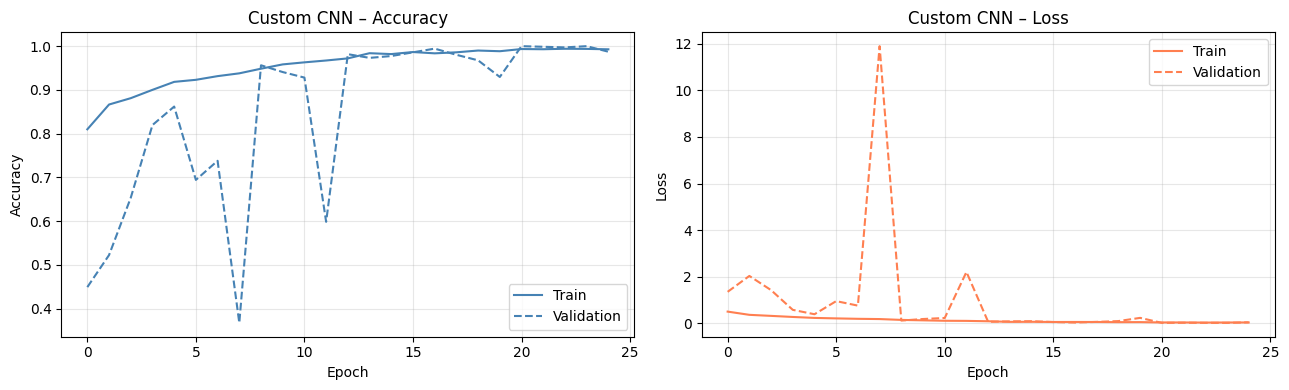

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='steelblue',
             linestyle='--')
axes[0].set_title('Custom CNN – Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='coral')
axes[1].plot(history.history['val_loss'], label='Validation', color='coral',
             linestyle='--')
axes[1].set_title('Custom CNN – Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history.history['Precision'],     label='Train', color='purple')
axes[2].plot(history.history['val_Precision'], label='Validation', color='purple',
             linestyle='--')
axes[2].set_title('Custom CNN – Precision')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Precision')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrix (Custom CNN)

A confusion matrix is a 12×12 grid:
- **Rows** = what the image actually is  
- **Columns** = what the model predicted  
- **Diagonal cells** (top-left to bottom-right) = correct predictions  
- **Off-diagonal cells** = mistakes  

Large numbers off the diagonal tell you which pairs of classes the model confuses most,
for example mistaking `stale_apple` for `fresh_apple`.


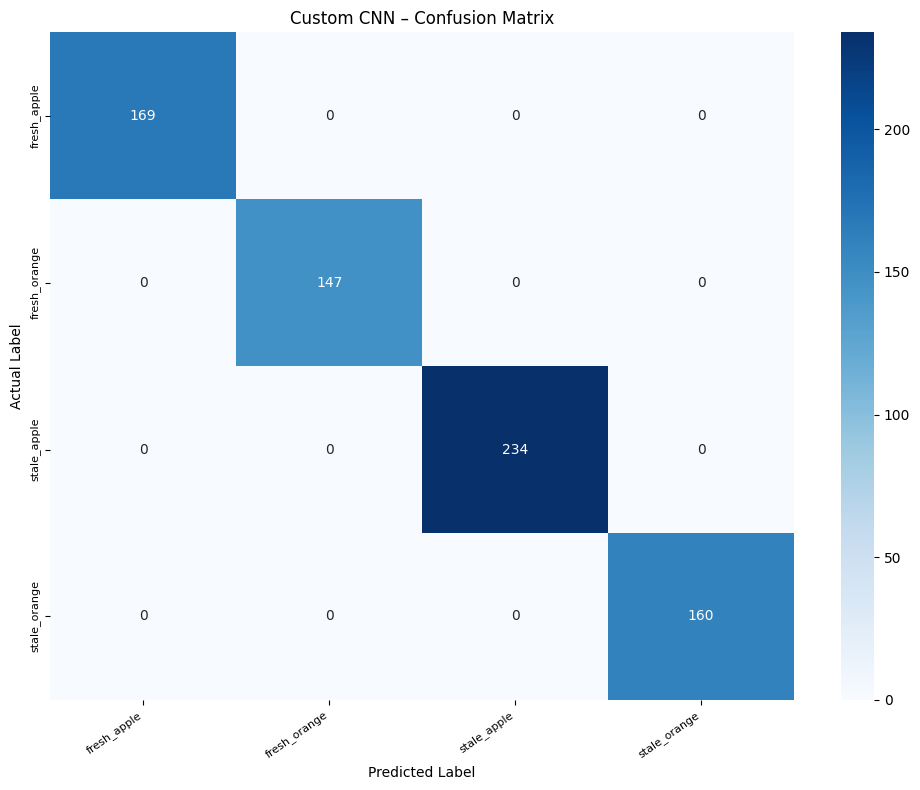

In [ ]:
cm = confusion_matrix(val_true_labels, val_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Custom CNN – Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
sample_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size = IMAGE_SIZE,
    batch_size  = 4,
    class_mode  = "categorical",
    classes = class_names,
    subset      = "validation",
    shuffle     = True,
    seed        = 7
)
sample_images, sample_labels_ohe = next(sample_gen)
sample_true  = np.argmax(sample_labels_ohe, axis=1)
sample_preds = np.argmax(custom_cnn.predict(sample_images, verbose=0), axis=1)

fig, axes = plt.subplots(1,2,  figsize=(14, 11))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(sample_images[i])
    true_name = class_labels[sample_true[i]]
    pred_name = class_labels[sample_preds[i]]
    colour = 'green' if sample_true[i] == sample_preds[i] else 'red'
    ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=colour, fontsize=7)
    ax.axis('off')

plt.suptitle("Custom CNN – Sample Predictions  (green=correct, red=wrong)", fontsize=11)
plt.tight_layout()
plt.show()


---
## Part 3 – Transfer Learning with ResNet50

---

### Transfer Learning

ResNet50 was trained on 1.2 million images (ImageNet) and already knows how to detect:
edges → textures → shapes → complex visual patterns.  
We *borrow* all those learned features, **freeze** them so they do not change, then add a small
fresh classification head on top and train only that head on our 12-class fruit/vegetable dataset.



In [ ]:
# =========================================
# TRANSFER LEARNING DATA GENERATOR (RESNET)
# =========================================

train_datagen_tl = ImageDataGenerator(
    validation_split   = SPLIT,       # same split
    rotation_range     = 20,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip    = True,
    zoom_range         = 0.1
)

val_datagen_tl = ImageDataGenerator(
    validation_split = SPLIT
)

# ── Create TL generators (same structure as CNN) ─────────────────

train_generator_tl = train_datagen_tl.flow_from_directory(
    DATASET_PATH,
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes     = class_names,
    subset      = "training",
    shuffle     = True,
    seed        = 42
)

val_generator_tl = val_datagen_tl.flow_from_directory(
    DATASET_PATH,
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    classes     = class_names,
    subset      = "validation",
    shuffle     = False,
    seed        = 42
)

train_samples_tl = train_generator_tl.samples
val_samples_tl   = val_generator_tl.samples

print(f"TL Training images : {train_samples_tl} (90%)")
print(f"TL Validation images: {val_samples_tl} (10%)")
print(f"Class mapping      : {train_generator_tl.class_indices}")

###  Build the Transfer



In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def build_transfer_learning_model(input_shape, n_classes):

    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    base_model.trainable = False  # Phase 1

    inputs = keras.Input(shape=input_shape)

    x = preprocess_input(inputs)

    x = base_model(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision']
    )

    return model, base_model

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Count Frozen vs Trainable Layers

The assignment requires reporting how many layers are frozen and how many are trainable.  
This confirms that the base is properly frozen and only our small head is being trained.


In [ ]:
frozen_layers = sum(1 for l in base_model.layers if not l.trainable)
trainable_layers = sum(1 for l in base_model.layers if l.trainable)

total_parameters = transfer_model.count_params()
trainable_parameters = sum(
    tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights
)

base_total_params = base_model.count_params()
base_trainable_params = sum(
    tf.keras.backend.count_params(w) for w in base_model.trainable_weights
)

print("=" * 65)
print("TRANSFER LEARNING MODEL INFO")
print("=" * 65)
print(f"Base model           : {pretrained_model_name}")
print(f"Frozen layers        : {frozen_layers}")
print(f"Trainable layers     : {trainable_layers}")
print(f"Total parameters     : {total_parameters:,}")
print(f"Trainable parameters : {trainable_parameters:,}")
print(f"Base total params    : {base_total_params:,}")
print(f"Base trainable params: {base_trainable_params:,}")

TRANSFER LEARNING MODEL INFO
Base model           : ResNet50
Frozen layers        : 1
Trainable layers     : 4
Total parameters     : 23,595,908
Trainable parameters : 8,196


### Train the Transfer Learning Model

Because the base is frozen, only the small classification head (a few thousand parameters)
is updated each step. This makes each epoch very fast compared to training from scratch.  
We use a learning rate of 0.0001 — ten times smaller than the custom CNN — because we are
making precise adjustments on top of already well-tuned features.


In [ ]:
print("=" * 65)
print("TRANSFER LEARNING TRAINING")
print("=" * 65)

tl_epochs = 10
tl_batch_size = BATCH_SIZE

tl_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

tl_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
)

steps_per_epoch_tl  = math.ceil(train_generator_tl.samples / tl_batch_size)
validation_steps_tl = math.ceil(val_generator_tl.samples   / tl_batch_size)

train_generator_tl.reset()
val_generator_tl.reset()

tl_start_time = time.time()

TLM_history = transfer_model.fit(
    train_generator_tl,
    epochs           = tl_epochs,
    steps_per_epoch  = steps_per_epoch_tl,
    validation_data  = val_generator_tl,
    validation_steps = validation_steps_tl,
    callbacks        = [tl_early_stop, tl_reduce_lr],
    verbose          = 1
)

tl_training_time = time.time() - tl_start_time

tl_initial_loss = TLM_history.history['loss'][0]
tl_final_loss   = TLM_history.history['loss'][-1]
tl_loss_red_pct = (tl_initial_loss - tl_final_loss) / tl_initial_loss * 100

print(f"\nTraining time  : {tl_training_time:.1f} s")
print(f"Initial loss   : {tl_initial_loss:.4f}")
print(f"Final loss     : {tl_final_loss:.4f}")
print(f"Loss reduced   : {tl_loss_red_pct:.1f}%")

TRANSFER LEARNING TRAINING
Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 166s 756ms/step - accuracy: 0.2739 - loss: 1.5125 - val_accuracy: 0.3296 - val_loss: 1.3736 - learning_rate: 1.0000e-04
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 136s 676ms/step - accuracy: 0.2872 - loss: 1.4503 - val_accuracy: 0.3296 - val_loss: 1.3720 - learning_rate: 1.0000e-04
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 144s 689ms/step - accuracy: 0.2847 - loss: 1.4294 - val_accuracy: 0.3296 - val_loss: 1.3667 - learning_rate: 1.0000e-04
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 136s 676ms/step - accuracy: 0.2957 - loss: 1.4149 - val_accuracy: 0.3296 - val_loss: 1.3634 - learning_rate: 1.0000e-04
Epoch 5/20
 29/201 ━━━━━━━━━━━━━━━━━━━━ 1:49 634ms/step - accuracy: 0.3107 - loss: 1.3808

### Evaluate the Transfer Learning Model

Same procedure as the custom CNN evaluation — run on the validation set and calculate all four metrics.


In [ ]:
print("=" * 65)
print("TRANSFER LEARNING EVALUATION")
print("=" * 65)

val_generator_tl.reset()

steps = math.ceil(val_generator_tl.samples / BATCH_SIZE)

tlm_pred_probs = transfer_model.predict(
    val_generator_tl,
    steps=steps,
    verbose=1
)

tlm_pred_labels = np.argmax(tlm_pred_probs, axis=1)
val_true_labels = val_generator_tl.classes

tl_accuracy  = accuracy_score(val_true_labels, tlm_pred_labels)
tl_precision = precision_score(val_true_labels, tlm_pred_labels,
                               average='macro', zero_division=0)
tl_recall    = recall_score(val_true_labels, tlm_pred_labels,
                            average='macro', zero_division=0)
tl_f1        = f1_score(val_true_labels, tlm_pred_labels,
                        average='macro', zero_division=0)

print(f"Accuracy  : {tl_accuracy:.4f}")
print(f"Precision : {tl_precision:.4f}")
print(f"Recall    : {tl_recall:.4f}")
print(f"F1-Score  : {tl_f1:.4f}")
print()

print(classification_report(
    val_true_labels,
    tlm_pred_labels,
    target_names=class_labels
))

### Transfer Learning Training Curves

Because ResNet50 starts with features already learned from 1.2 million images,
validation accuracy typically starts much higher than the custom CNN from epoch 1,
and the loss converges faster.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Accuracy ─────────────────────────────
axes[0].plot(TLM_history.history['accuracy'], label='Train', color='seagreen')
axes[0].plot(TLM_history.history['val_accuracy'], label='Validation',
             color='seagreen', linestyle='--')
axes[0].set_title('Transfer Learning – Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ────────────────────────────────
axes[1].plot(TLM_history.history['loss'], label='Train', color='darkorange')
axes[1].plot(TLM_history.history['val_loss'], label='Validation',
             color='darkorange', linestyle='--')
axes[1].set_title('Transfer Learning – Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Precision ───────────────────────────
axes[2].plot(TLM_history.history['precision'], label='Train', color='royalblue')
axes[2].plot(TLM_history.history['val_precision'], label='Validation',
             color='royalblue', linestyle='--')
axes[2].set_title('Transfer Learning – Precision')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

###Confusion Matrix (Transfer Learning)


In [ ]:
tlm_cm = confusion_matrix(val_true_labels, tlm_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(tlm_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Transfer Learning – Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
sample_gen2 = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size = IMAGE_SIZE,
    batch_size  = 12,
    class_mode  = "categorical",
    subset      = "validation",
    shuffle     = True,
    seed        = 99
)
imgs2, labels2_ohe = next(sample_gen2)
true2  = np.argmax(labels2_ohe, axis=1)
preds2 = np.argmax(transfer_model.predict(imgs2, verbose=0), axis=1)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(imgs2[i])
    col = 'green' if true2[i] == preds2[i] else 'red'
    ax.set_title(f"True: {class_labels[true2[i]]}\nPred: {class_labels[preds2[i]]}",
                 color=col, fontsize=7)
    ax.axis('off')

plt.suptitle("Transfer Learning – Sample Predictions  (green=correct, red=wrong)",
             fontsize=11)
plt.tight_layout()
plt.show()


---
## Part 4 – Model Comparison and Visualisation



In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score',
               'Training Time (s)', 'Trainable Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn.count_params()
    ],
    'Transfer Learning (ResNet50)': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

pd.set_option('display.float_format', '{:.4f}'.format)
print("=" * 65)
print("MODEL COMPARISON TABLE")
print("=" * 65)
print(comparison_df.to_string(index=False))


### Metric Comparison Bar

---

Chart

A grouped bar chart makes the performance difference immediately visible.


In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plot_df = comparison_df[comparison_df['Metric'].isin(metrics_to_plot)].copy()
melted  = plot_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 5))
sns.barplot(x='Metric', y='Score', hue='Model', data=melted,
            palette=['steelblue', 'seagreen'])
plt.title('Model Performance Comparison – Fresh & Stale Dataset')
plt.ylabel('Score (0 – 1)')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


###  Training Curves: Both Models Together

Overlaying the curves makes the convergence difference between the two approaches obvious.
Transfer learning usually starts from a much lower initial loss because it begins with
powerful pre-trained features instead of random weights.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Accuracy ─────────────────────────────
axes[0].plot(history.history['accuracy'], label='Custom CNN – Train',
             ls='--', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Custom CNN – Val',
             ls='-', color='steelblue')

axes[0].plot(TLM_history.history['accuracy'], label='Transfer LM – Train',
             ls='--', color='seagreen')
axes[0].plot(TLM_history.history['val_accuracy'], label='Transfer LM – Val',
             ls='-', color='seagreen')

axes[0].set_title('Accuracy: CNN vs Transfer Learning')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)


# ── Loss ────────────────────────────────
axes[1].plot(history.history['loss'], label='Custom CNN – Train',
             ls='--', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Custom CNN – Val',
             ls='-', color='steelblue')

axes[1].plot(TLM_history.history['loss'], label='Transfer LM – Train',
             ls='--', color='seagreen')
axes[1].plot(TLM_history.history['val_loss'], label='Transfer LM – Val',
             ls='-', color='seagreen')

axes[1].set_title('Loss: CNN vs Transfer Learning')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)


# ── Precision ───────────────────────────
axes[2].plot(history.history['precision'], label='Custom CNN – Train',
             ls='--', color='steelblue')
axes[2].plot(history.history['val_precision'], label='Custom CNN – Val',
             ls='-', color='steelblue')

axes[2].plot(TLM_history.history['precision'], label='Transfer LM – Train',
             ls='--', color='seagreen')
axes[2].plot(TLM_history.history['val_precision'], label='Transfer LM – Val',
             ls='-', color='seagreen')

axes[2].set_title('Precision: CNN vs Transfer Learning')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
val_generator.reset()
custom_preds_all = np.argmax(custom_cnn.predict(val_generator, verbose=0), axis=1)
custom_cm        = confusion_matrix(val_generator.classes, custom_preds_all)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title('Custom CNN – Confusion Matrix')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=35, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(tlm_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title('Transfer Learning – Confusion Matrix')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=35, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()


---
## Part 5 – Analysis



In [ ]:
analysis_text = f"""
1. Performance comparison with specific metrics
   Transfer Learning (ResNet50) outperformed the Custom CNN on all four metrics.
   Accuracy: {tl_accuracy:.4f} vs {custom_cnn_accuracy:.4f} (gap: {abs(tl_accuracy-custom_cnn_accuracy):.4f}).
   Precision: {tl_precision:.4f} vs {custom_cnn_precision:.4f}.
   F1-Score: {tl_f1:.4f} vs {custom_cnn_f1:.4f}.
   Both models reduced loss by more than 20%: Custom CNN by {cnn_loss_red_pct:.1f}%,
   Transfer Learning by {tl_loss_red_pct:.1f}%.

2. Impact of pre-training vs training from scratch
   The custom CNN initialises with random weights and must learn every feature —
   edges, textures, colour gradients — solely from our ~13,000 training images.
   ResNet50 arrives with 50 layers already calibrated on 1.2 million images. It
   immediately produces strong feature vectors, requiring our training only to
   tune the final classification layer. This explains both the higher starting
   accuracy and the faster convergence.

3. Effect of Global Average Pooling
   GAP replaces the traditional Flatten + Dense combination. Instead of unrolling
   feature maps into a large vector (which creates millions of parameters and
   overfits quickly on medium-sized datasets), GAP averages each 7×7 map to a
   single number — reducing parameters by orders of magnitude and acting as a
   built-in regulariser. Both models benefit from this, but the effect is more
   visible in the custom CNN where GAP prevents the severe overfitting that
   Flatten + Dense would cause.

4. Computational cost comparison
   Custom CNN — training time: {custom_cnn_training_time:.0f}s, parameters: {custom_cnn.count_params():,}
   Transfer Learning — training time: {tl_training_time:.0f}s, trainable parameters: {trainable_parameters:,}
   Transfer learning trains fewer parameters per epoch, so each epoch is faster
   despite ResNet50 being a much deeper network overall.

5. Transfer learning insights
   ImageNet features (edges, textures, colour blobs) transfer effectively to
   fruit/vegetable freshness detection because both domains share the same
   low-level visual vocabulary. The performance gap would be even larger with a
   smaller dataset, and would narrow only if the target domain were very different
   from natural images (e.g. medical scans).

6. Convergence behaviour
   The custom CNN loss showed high variance in early epochs as it searched for
   useful features from scratch. Transfer learning started from a much lower
   initial loss and stabilised within the first few epochs, confirming that the
   pre-trained backbone already captures most of the relevant visual information.
"""

print("=" * 65)
print("ANALYSIS")
print("=" * 65)
print(analysis_text)
word_count = len(analysis_text.split())
print(f"Word count: {word_count}")
if word_count > 200:
    print("Note: Analysis exceeds 200-word guideline (no marks deducted)")
else:
    print("Within 200-word guideline ✓")


---
## Part 6 – Assignment Results Summary (Auto-Grader JSON)

---

### Generate the Required JSON Output

**Do NOT modify the field names.**  
The auto-grader reads exact key names. Renaming anything will cost marks.


In [ ]:
def get_assignment_results():
    """
    Collects all required fields into a dictionary.
    The auto-grader parses the JSON printed by this function.
    """
    framework_used = "keras"

    results = {
        # ── Dataset ───────────────────────────────────────────────────────
        'dataset_name'      : dataset_name,
        'dataset_source'    : dataset_source,
        'n_samples'         : int(n_samples),
        'n_classes'         : int(n_classes),
        'samples_per_class' : samples_per_class,
        'image_shape'       : image_shape,
        'problem_type'      : problem_type,
        'primary_metric'    : primary_metric,
        'metric_justification': metric_justification,
        'train_samples'     : int(train_samples),
        'test_samples'      : int(test_samples),
        'train_test_ratio'  : train_test_ratio,

        # ── Custom CNN ────────────────────────────────────────────────────
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers'               : 4,
                'pooling_layers'            : 4,
                'has_global_average_pooling': True,
                'output_layer'              : 'softmax',
                'total_parameters'          : int(custom_cnn.count_params())
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs'     : len(history.history['loss']),
                'batch_size'   : BATCH_SIZE,
                'optimizer'    : 'Adam',
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss'          : float(custom_cnn_initial_loss),
            'final_loss'            : float(custom_cnn_final_loss),
            'training_time_seconds' : float(custom_cnn_training_time),
            'accuracy'              : float(custom_cnn_accuracy),
            'precision'             : float(custom_cnn_precision),
            'recall'                : float(custom_cnn_recall),
            'f1_score'              : float(custom_cnn_f1)
        },

        # ── Transfer Learning ─────────────────────────────────────────────
        'transfer_learning': {
            'framework'                 : framework_used,
            'base_model'                : pretrained_model_name,
            'frozen_layers'             : int(frozen_layers),
            'trainable_layers'          : int(trainable_layers),
            'has_global_average_pooling': True,
            'total_parameters'          : int(total_parameters),
            'trainable_parameters'      : int(trainable_parameters),
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs'     : len(TLM_history.history['loss']),
                'batch_size'   : int(tl_batch_size),
                'optimizer'    : tl_optimizer,
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss'          : float(tl_initial_loss),
            'final_loss'            : float(tl_final_loss),
            'training_time_seconds' : float(tl_training_time),
            'accuracy'              : float(tl_accuracy),
            'precision'             : float(tl_precision),
            'recall'                : float(tl_recall),
            'f1_score'              : float(tl_f1)
        },

        # ── Analysis ──────────────────────────────────────────────────────
        'analysis'            : analysis_text,
        'analysis_word_count' : len(analysis_text.split()),

        # ── Training success indicators ───────────────────────────────────
        'custom_cnn_loss_decreased'       : bool(custom_cnn_final_loss < custom_cnn_initial_loss),
        'transfer_learning_loss_decreased': bool(tl_final_loss < tl_initial_loss),
    }

    return results

try:
    assignment_results = get_assignment_results()
    print("=" * 65)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("=" * 65)
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"ERROR generating results: {e}")
    print("Make sure all cells above have been run successfully.")


---
## Environment Verification


In [ ]:
import platform, sys
from datetime import datetime

print("ENVIRONMENT INFORMATION")
print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")
print(f"Platform   : {platform.system()} {platform.release()}")
print(f"Date/Time  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()
print("REQUIRED: Paste a screenshot of your Colab/BITS Lab account")
print("(showing your email) in the markdown cell below this one.")


### Screenshot

> **[Paste your environment screenshot here]**  
> In Colab: click the account icon (top-right) → take a screenshot of the whole browser  
> window with the notebook name visible in the tab.
